In [77]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 10.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.6/739.6 kB 10.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchaudio]2 [torchaudio]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## checking the different emg patterns




NameError: name 'time_a' is not defined

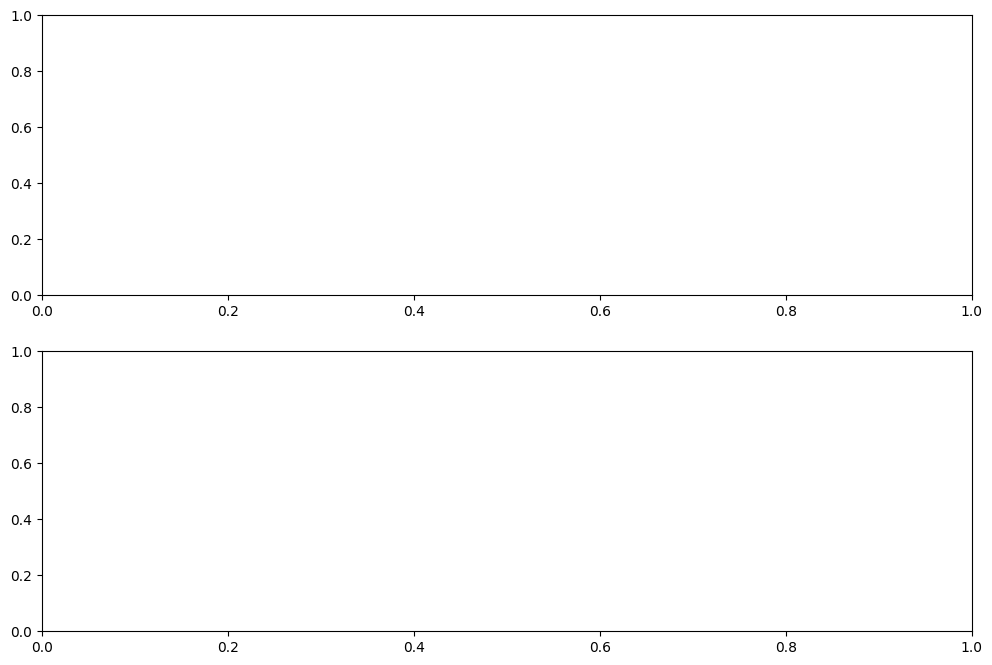

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Stress EMG
axes[0].plot(time_a[:1000], dfa['emg1'].values[:1000], 'r-', label='EMG1', linewidth=1.5)
axes[0].plot(time_a[:1000], dfa['emg2'].values[:1000], 'b-', label='EMG2', linewidth=1.5)
axes[0].set_title('Stress - EMG Signals', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Focus EMG
axes[1].plot(time_b[:1000], dfb['emg1'].values[:1000], 'r-', label='EMG1', linewidth=1.5)
axes[1].plot(time_b[:1000], dfb['emg2'].values[:1000], 'b-', label='EMG2', linewidth=1.5)
axes[1].set_title('Focus - EMG Signals', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Applying 16 4 for all the samples

In [8]:
import os, glob
import numpy as np
import pandas as pd

DATA_DIR = "data/my_raw_data"

# Label mapping from filenames
label_map = {
    "baseline": "relaxed",
    "focus": "focused",
    "distract": "distracted",
    "stress": "stressed"
}

all_cols = ["host_time_s","t_ms","ax1","ay1","az1","gx1","gy1","gz1","yaw1","pitch1","roll1",
            "ax2","ay2","az2","gx2","gy2","gz2","yaw2","pitch2","roll2","emg1","emg2"]

time_cols = ["host_time_s", "t_ms"]
feature_cols = [c for c in all_cols if c not in time_cols]


WINDOW_SIZE = 125
STEP_SIZE = int(WINDOW_SIZE/5)

print(f"Features: {len(feature_cols)}")
print(f"Window size: {WINDOW_SIZE}, Step: {STEP_SIZE}")

Features: 20
Window size: 125, Step: 25


In [9]:
def infer_label_from_filename(fname: str) -> str:
    lower = fname.lower()
    for key, lab in label_map.items():
        if key in lower:
            return lab
    raise ValueError(f"Could not infer label for: {fname}")


In [10]:
X_list = []
y_list = []

all_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print("Found files:", [os.path.basename(f) for f in all_files])

for fpath in all_files:
    fname = os.path.basename(fpath)
    print(f"\nProcessing {fname}...")

    df = pd.read_csv(fpath)

    '''for col in feature_cols:
        if col in df.columns:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()'''

    '''norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values'''
    data = df[feature_cols].dropna().values
    label = infer_label_from_filename(fname)

    window_size = WINDOW_SIZE
    step_size = STEP_SIZE
    print(f"  Using window_size={window_size}, step_size={step_size}")

    n_samples = data.shape[0]
    start = 0
    while start + WINDOW_SIZE <= len(data):
        window = data[start:start + WINDOW_SIZE]  # raw window (WINDOW_SIZE, n_features)

        # Per-window z-score normalization - EXACTLY like inference
        window_mean = np.mean(window, axis=0, keepdims=True)
        window_std  = np.std(window, axis=0, keepdims=True)
        window_norm = (window - window_mean) / (window_std + 1e-8)

        X_list.append(window_norm)
        y_list.append(label)
        start += STEP_SIZE
    

X = np.stack(X_list, axis=0)
y = np.array(y_list)

print("\n✅ Dataset created!")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", np.unique(y, return_counts=True))


Found files: ['adi2_7_5min_distract.csv', 'soup_7_5min_focus.csv', 'adi1_7_5min_distract.csv', 'emmanuel1_7_5min_baseline.csv', 'jun_5_7min_distract.csv', 'louis1_7_5min_distract.csv', 'adi2_7_5min_focus.csv', 'soup_7_5min_distract.csv', 'louis2_7_5min_distract.csv', 'adi2_7_5min_stress.csv', 'jun_5_7min_stress.csv', 'louis2_7_5min_stress.csv', 'louis2_7_5min_baseline.csv', 'soup_7_5min_baseline.csv', 'TT_7_5min_stress.csv', 'louis1_7_5min_baseline.csv', 'jun_5_7min_baseline.csv', 'adi1_7_5min_stress.csv', 'emmanuel1_7_5min_distract.csv', 'louis2_7_5min_focus.csv', 'louis1_7_5min_stress.csv', 'jun_5_7min_focus.csv', 'adi1_7_5min_baseline.csv', 'adi2_7_5min_baseline.csv', 'emm2_7_5min_baseline.csv', 'louis1_7_5min_focus.csv', 'emm2_7_5min_stress.csv', 'emm2_7_5min_focus.csv', 'TT_7_5min_baseline.csv', 'TT_7_5min_focus.csv', 'emmanuel1_7_5min_focus.csv', 'emmanuel1_7_5min_stress.csv', 'TT_7_5min_distract.csv', 'soup_7_5min_stress.csv', 'emm2_7_5min_distract.csv', 'adi1_7_5min_focus.csv']

In [7]:
from preprocessing import create_training_dataset
DATA_DIR = "data/my_raw_data"


X_int, y_int, labels = create_training_dataset(data_dir=DATA_DIR, ignore_files=[
    "focus_test.csv",
    "stress_w_20sec_baseline.csv",
    "adi_focused.csv",
    "louis_focused.csv",
    "louis_stressed.csv",
    "adi_stressed.csv"] )

print("Dataset shapes:", X_int.shape, y_int.shape)

#X_train, X_val, y_train, y_val = train_test_split(
#    X_int, y_int, test_size=0.2, random_state=42, stratify=y_int
#)
#print("Training set:", X_train.shape, y_train.shape)

Using 36 training files (ignored 0 test/backup files)
Processing adi2_7_5min_distract.csv...
Processing soup_7_5min_focus.csv...
Processing adi1_7_5min_distract.csv...
Processing emmanuel1_7_5min_baseline.csv...
Processing jun_5_7min_distract.csv...
Processing louis1_7_5min_distract.csv...
Processing adi2_7_5min_focus.csv...
Processing soup_7_5min_distract.csv...
Processing louis2_7_5min_distract.csv...
Processing adi2_7_5min_stress.csv...
Processing jun_5_7min_stress.csv...
Processing louis2_7_5min_stress.csv...
Processing louis2_7_5min_baseline.csv...
Processing soup_7_5min_baseline.csv...
Processing TT_7_5min_stress.csv...
Processing louis1_7_5min_baseline.csv...
Processing jun_5_7min_baseline.csv...
Processing adi1_7_5min_stress.csv...
Processing emmanuel1_7_5min_distract.csv...
Processing louis2_7_5min_focus.csv...
Processing louis1_7_5min_stress.csv...
Processing jun_5_7min_focus.csv...
Processing adi1_7_5min_baseline.csv...
Processing adi2_7_5min_baseline.csv...
Processing emm2_

In [82]:
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(y)
print("Label mapping:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

y_cat = F.one_hot(torch.tensor(y_int)).numpy()

# Train val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y_int, test_size=0.2, random_state=42, stratify=y_int
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")

Label mapping: {np.str_('distracted'): 0, np.str_('focused'): 1, np.str_('relaxed'): 2, np.str_('stressed'): 3}

Train: 13001 samples
Val:   3251 samples


In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_torch = torch.FloatTensor(X_train).transpose(1, 2)
# X_train_torch = torch.FloatTensor(X_train)

X_val_torch   = torch.FloatTensor(X_val).transpose(1, 2)
# X_val_torch   = torch.FloatTensor(X_val)

y_train_torch = torch.LongTensor(y_train)
y_val_torch   = torch.LongTensor(y_val)

print(f"X_train_torch shape: {X_train_torch.shape}")
print(f"X_val_torch shape:   {X_val_torch.shape}")

BATCH_SIZE = 32
train_dataset = TensorDataset(X_train_torch, y_train_torch)
val_dataset   = TensorDataset(X_val_torch,   y_val_torch)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

for batch_X, batch_y in train_loader:
    print(f"FIRST BATCH shape: {batch_X.shape}")
    break

Using device: cpu
X_train_torch shape: torch.Size([13001, 20, 125])
X_val_torch shape:   torch.Size([3251, 20, 125])
FIRST BATCH shape: torch.Size([32, 20, 125])


In [ ]:
# Train REGULARIZED version
# class EmotionCNN_Reg(nn.Module):
#     def __init__(self, input_channels=20, num_classes=4):
#         super().__init__()
#         self.conv1 = nn.Conv1d(input_channels, 16, kernel_size=3, padding=1)
#         self.bn1   = nn.BatchNorm1d(16)
#         self.pool1 = nn.MaxPool1d(2)

#         self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
#         self.bn2   = nn.BatchNorm1d(32)
#         self.pool2 = nn.MaxPool1d(2)

#         self.fc1       = nn.Linear(32 * 4, 64)
#         self.dropout1  = nn.Dropout(0.3)
#         self.fc2       = nn.Linear(64, 32)
#         self.dropout2  = nn.Dropout(0.5)
#         self.fc3       = nn.Linear(32, num_classes)

#     def forward(self, x):
#         x = F.relu(self.bn1(self.conv1(x)))
#         x = self.pool1(x)
#         x = F.dropout(x, 0.2)

#         x = F.relu(self.bn2(self.conv2(x)))
#         x = self.pool2(x)

#         x = x.view(x.size(0), -1)
#         x = F.relu(self.fc1(x))
#         x = self.dropout1(x)
#         x = F.relu(self.fc2(x))
#         x = self.dropout2(x)
#         x = self.fc3(x)
#         return x

# # Retrain with regularization
# model_reg = EmotionCNN_Reg(input_channels=X_train_torch.shape[1],
#                            num_classes=4).to(device)
# optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-3)
# criterion = nn.CrossEntropyLoss()

# print("🛡️ Training regularized model...")
# print("Input channels:", X_train_torch.shape[1])
# print("Total params:", sum(p.numel() for p in model_reg.parameters()))


🛡️ Training regularized model...
Input channels: 20
Total params: 13108


In [8]:
# Train REGULARIZED version
class EmotionCNN_Reg(nn.Module):
    def __init__(self, input_channels=20, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv1d(input_channels, 16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)

        self.fc1       = nn.Linear(32*31 , 64)
        self.dropout1  = nn.Dropout(0.3)
        self.fc2       = nn.Linear(64, 32)
        self.dropout2  = nn.Dropout(0.5)
        self.fc3       = nn.Linear(32, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.dropout(x, 0.2)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

#Retrain with regularization
model_reg = EmotionCNN_Reg(input_channels=X_train_torch.shape[1],
                           num_classes=4).to(device)
optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss()

print("🛡️ Training regularized model...")
print("Input channels:", X_train_torch.shape[1])
print("Total params:", sum(p.numel() for p in model_reg.parameters()))



X_train_torch.shape[1]

🛡️ Training regularized model...
Input channels: 20
Total params: 68404


20

In [84]:
# Create a convolutional neural network 
class EmotionCNN_RegV2(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv1d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, 
                      stride=1, 
                      padding=1), 
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(),
            nn.Conv1d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv1d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_units),
            nn.Conv1d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from? 
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*31 ,out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        # print(x.shape)
        x = self.block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x

torch.manual_seed(42)
model_2 = EmotionCNN_RegV2(input_shape=1,hidden_units=10, output_shape=4).to(device)
model_2

EmotionCNN_RegV2(
  (block_1): Sequential(
    (0): Conv1d(1, 10, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(10, 10, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv1d(10, 10, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv1d(10, 10, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=310, out_features=4, bias=True)
  )
)

### Custom Loss function

In [85]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CostSensitiveLoss(nn.Module):
    def __init__(self, cost_matrix):
        super(CostSensitiveLoss, self).__init__()
        # Ensure the matrix is a PyTorch tensor on the correct device (CPU/GPU)
        self.cost_matrix = torch.tensor(cost_matrix, dtype=torch.float32)

    def forward(self, logits, targets):
        # 1. Convert the raw model outputs (logits) into percentages (0.0 to 1.0)
        probs = F.softmax(logits, dim=1)
        
        # 2. Match the penalty matrix device to the targets device
        self.cost_matrix = self.cost_matrix.to(targets.device)
        
        # 3. Pull the specific penalty rows for the true classes in this batch
        # If the target is 3 (Relaxed), it pulls the [1.0, 10.0, 1.0, 0.0] row
        batch_costs = self.cost_matrix[targets]
        
        # 4. Multiply the model's predicted probabilities by the penalties
        # If it predicted "Stressed" (column 1) with 90% confidence, 
        # the loss explodes: 0.90 * 10.0 penalty = Huge Loss!
        expected_costs = torch.sum(batch_costs * probs, dim=1)
        
        # 5. Return the average loss for the batch
        return torch.mean(expected_costs)

In [86]:
# Define your Risk Averse penalties
'''penalty_grid = [
    [0.0, 1.0, 1.0, 1.5],  # True: Distracted
    [1.0, 0.0, 1.0, 1.5],  # True: Focused
    [1.0, 1.0, 0.0, 1.5],  # True: Relaxed
    [1.0, 1.0, 1.0, 0.0]  # True: Stressed
]'''
penalty_grid = [
    [0.0, 1.0, 1.0, 1.5],  # True: Distracted
    [1.0, 0.0, 1.0, 1.5],  # True: Focused
    [1.0, 1.5, 0.0, 1.8],  # True: Relaxed
    [1.0, 1.0, 1.0, 0.0]  # True: Stressed
]

### Testing first model

In [13]:
# Use REGULARIZED model
model_reg = EmotionCNN_Reg(input_channels=X_train_torch.shape[1],
                           num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
# criterion = CostSensitiveLoss(cost_matrix=penalty_grid)
optimizer = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 100
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0

print("🛡️ Training REGULARIZED model...")
print(f"Input channels: {len(feature_cols)}")
print(f"Total params: {sum(p.numel() for p in model_reg.parameters()):,}")

for epoch in range(EPOCHS):
    # Training
    model_reg.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model_reg(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

    # Validation
    model_reg.eval()
    val_loss = 0.0
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model_reg(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()

    # Metrics
    train_loss = running_loss / len(train_loader)
    val_loss_epoch = val_loss / len(val_loader)
    train_acc = 100 * correct_train / total_train
    val_acc = 100 * correct_val / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss_epoch)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss_epoch)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_reg.state_dict(), "best_emotion_cnn_reg.pth")

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(
            f"Epoch {epoch+1}/{EPOCHS}: "
            f"Train: {train_loss:.4f} ({train_acc:.1f}%) | "
            f"Val: {val_loss_epoch:.4f} ({val_acc:.1f}%)"
        )

print(f"\n✅ Best val accuracy: {best_val_acc:.1f}%")
print("💾 Saved: best_emotion_cnn_reg.pth")


🛡️ Training REGULARIZED model...
Input channels: 20
Total params: 68,404
Epoch 1/100: Train: 1.3935 (25.3%) | Val: 1.3647 (35.6%)
Epoch 11/100: Train: 0.6084 (74.7%) | Val: 0.5807 (76.9%)
Epoch 21/100: Train: 0.3792 (86.5%) | Val: 0.4332 (82.6%)
Epoch 31/100: Train: 0.3015 (89.4%) | Val: 0.3844 (89.1%)
Epoch 41/100: Train: 0.2485 (91.5%) | Val: 0.3674 (89.5%)
Epoch 51/100: Train: 0.1261 (96.0%) | Val: 0.2937 (92.9%)
Epoch 61/100: Train: 0.1216 (96.8%) | Val: 0.3618 (91.9%)
Epoch 71/100: Train: 0.0952 (97.5%) | Val: 0.3208 (93.6%)
Epoch 81/100: Train: 0.1065 (97.1%) | Val: 0.3039 (93.1%)
Epoch 91/100: Train: 0.1032 (97.1%) | Val: 0.3439 (92.2%)
Epoch 100/100: Train: 0.1162 (96.9%) | Val: 0.3623 (91.7%)

✅ Best val accuracy: 94.5%
💾 Saved: best_emotion_cnn_reg.pth


In [87]:
# Use REGULARIZED model
model_reg2 = EmotionCNN_RegV2(input_shape=X_train_torch.shape[1],
                            hidden_units=10,
                            output_shape=4).to(device)
# criterion = nn.CrossEntropyLoss()
criterion = CostSensitiveLoss(cost_matrix=penalty_grid)
optimizer = optim.Adam(model_reg2.parameters(), lr=0.001, weight_decay=1e-3)
# optimizer = optim.SGD(model_reg2.parameters(), lr=0.01, momentum=0.9)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 100
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0

print("🛡️ Training REGULARIZED model...")
print(f"Input channels: {len(feature_cols)}")
print(f"Total params: {sum(p.numel() for p in model_reg2.parameters()):,}")

for epoch in range(EPOCHS):
    # Training
    model_reg2.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model_reg2(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

    # Validation
    model_reg2.eval()
    val_loss = 0.0
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model_reg2(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()

    # Metrics
    train_loss = running_loss / len(train_loader)
    val_loss_epoch = val_loss / len(val_loader)
    train_acc = 100 * correct_train / total_train
    val_acc = 100 * correct_val / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss_epoch)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss_epoch)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_reg2.state_dict(), "emotionv2_tiny_vgg_updated_windowing.pth")

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(
            f"Epoch {epoch+1}/{EPOCHS}: "
            f"Train: {train_loss:.4f} ({train_acc:.1f}%) | "
            f"Val: {val_loss_epoch:.4f} ({val_acc:.1f}%)"
        )

print(f"\n✅ Best val accuracy: {best_val_acc:.1f}%")
print("💾 Saved: emotionv2_tiny_vgg.pth")


🛡️ Training REGULARIZED model...
Input channels: 20
Total params: 2,824
Epoch 1/100: Train: 0.6230 (39.3%) | Val: 0.5489 (45.4%)
Epoch 11/100: Train: 0.3072 (70.0%) | Val: 0.3637 (63.9%)
Epoch 21/100: Train: 0.2816 (72.9%) | Val: 0.2973 (72.1%)
Epoch 31/100: Train: 0.1813 (84.7%) | Val: 0.2011 (83.0%)
Epoch 41/100: Train: 0.1520 (87.3%) | Val: 0.2007 (81.6%)
Epoch 51/100: Train: 0.1287 (89.4%) | Val: 0.1704 (85.9%)
Epoch 61/100: Train: 0.1183 (90.2%) | Val: 0.1557 (87.4%)
Epoch 71/100: Train: 0.1104 (90.8%) | Val: 0.1461 (87.3%)
Epoch 81/100: Train: 0.1000 (91.9%) | Val: 0.1517 (86.2%)
Epoch 91/100: Train: 0.0848 (93.1%) | Val: 0.1370 (88.8%)
Epoch 100/100: Train: 0.0831 (93.3%) | Val: 0.1292 (89.4%)

✅ Best val accuracy: 89.8%
💾 Saved: emotionv2_tiny_vgg.pth


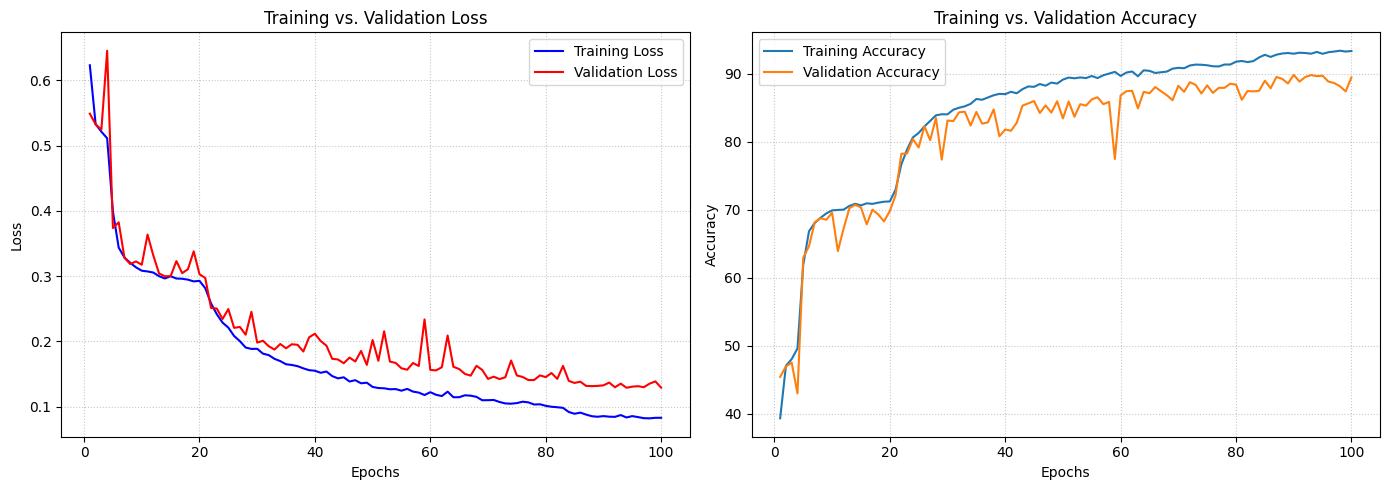

In [88]:
import matplotlib.pyplot as plt

# Create an array of epoch numbers for the x-axis
epochs = range(1, len(train_losses) + 1)

# Set up the figure size (width, height)
plt.figure(figsize=(14, 5))

# ==========================================
# Subplot 1: Training and Validation Loss
# ==========================================
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epochs, train_losses, label='Training Loss', color='blue')
plt.plot(epochs, val_losses, label='Validation Loss', color='red')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# ==========================================
# Subplot 2: Training and Validation Accuracy
# ==========================================
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epochs, train_accs, label='Training Accuracy')
plt.plot(epochs, val_accs, label='Validation Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Adjust layout so the plots don't overlap
plt.tight_layout()

# Display the plot
plt.show()

In [24]:
# Load BEST regularized model
model_reg.load_state_dict(torch.load('best_emotion_cnn_reg.pth'))
model_reg.eval()

# Get predictions
all_preds_reg = []
all_labels_reg = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to(device)
        outputs = model_reg(batch_X)
        _, predicted = torch.max(outputs, 1)
        all_preds_reg.extend(predicted.cpu().numpy())
        all_labels_reg.extend(batch_y.cpu().numpy())

print("📊 REGULARIZED MODEL RESULTS:")
print(classification_report(all_labels_reg, all_preds_reg,
                          target_names=label_encoder.classes_))


NameError: name 'model_reg' is not defined

In [96]:
# Load BEST regularized model
model_reg2.load_state_dict(torch.load('emotionv2_tiny_vgg_updated_windowing.pth'))
model_reg2.eval()

# Get predictions
all_preds_reg = []
all_labels_reg = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to(device)
        outputs = model_reg2(batch_X)
        _, predicted = torch.max(outputs, 1)
        all_preds_reg.extend(predicted.cpu().numpy())
        all_labels_reg.extend(batch_y.cpu().numpy())

print("📊 REGULARIZED MODEL RESULTS:")
print(classification_report(all_labels_reg, all_preds_reg,
                          target_names=label_encoder.classes_))

📊 REGULARIZED MODEL RESULTS:
              precision    recall  f1-score   support

  distracted       0.88      0.87      0.87       811
     focused       0.92      0.92      0.92       811
     relaxed       0.93      0.93      0.93       811
    stressed       0.87      0.87      0.87       818

    accuracy                           0.90      3251
   macro avg       0.90      0.90      0.90      3251
weighted avg       0.90      0.90      0.90      3251



<Figure size 1000x800 with 0 Axes>

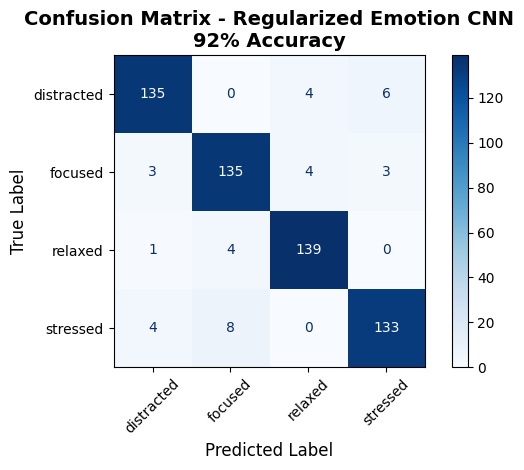

Confusion Matrix (True ↓ | Predicted →):
[[135   0   4   6]
 [  3 135   4   3]
 [  1   4 139   0]
 [  4   8   0 133]]

Class order: ['distracted' 'focused' 'relaxed' 'stressed']


In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels_reg, all_preds_reg)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Confusion Matrix - Regularized Emotion CNN\n92% Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("Confusion Matrix (True ↓ | Predicted →):")
print(cm)
print(f"\nClass order: {label_encoder.classes_}")


<Figure size 1000x800 with 0 Axes>

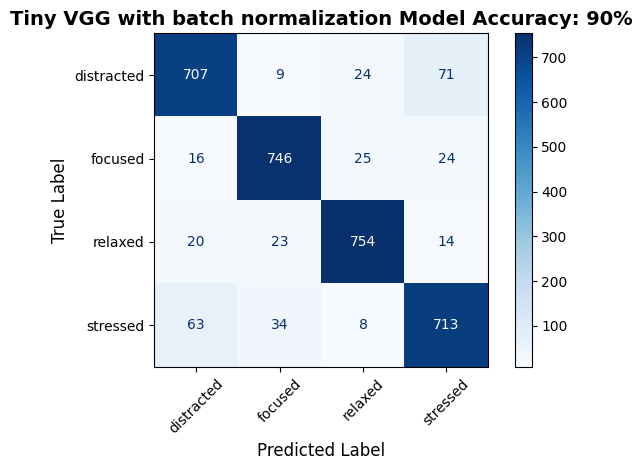

Confusion Matrix (True ↓ | Predicted →):
[[707   9  24  71]
 [ 16 746  25  24]
 [ 20  23 754  14]
 [ 63  34   8 713]]

Class order: ['distracted' 'focused' 'relaxed' 'stressed']


In [92]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels_reg, all_preds_reg)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Tiny VGG with batch normalization Model Accuracy: 90%', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("Confusion Matrix (True ↓ | Predicted →):")
print(cm)
print(f"\nClass order: {label_encoder.classes_}")

### Prediction

In [99]:
def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file using regularized model."""
    df = pd.read_csv(fpath)

    # Convert objects to numeric (same as training)
    for col in feature_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    data = df[feature_cols].dropna().values 

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        window = data[start:start + WINDOW_SIZE] 

        window_mean = np.mean(window, axis=0, keepdims=True)
        window_std  = np.std(window, axis=0, keepdims=True)
        window_norm = (window - window_mean) / (window_std + 1e-8)

        windows.append(window_norm)
        start += STEP_SIZE

    if not windows:
        return None, None

    X_new = np.stack(windows)  # (n_windows, 125, 14)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)  

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs

test_file = "EmoRecData/louis3_7_5min_focus.csv"
labels_reg, probs_reg = predict_file_reg(test_file, model_reg2, label_encoder)

# Fixed output display
filename = os.path.basename(test_file)
print(f"🛡️ REGULARIZED MODEL (94% val acc) on {filename}:")
print(f"🎯 {len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\n📊 PREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n🎯 TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f"📋 TRUE LABEL:     {true_label}")


🛡️ REGULARIZED MODEL (94% val acc) on louis3_7_5min_focus.csv:
🎯 445 windows predicted
Most common counts: [  3 106 315  21]

First 10 predictions:
   1: stressed
   2: stressed
   3: stressed
   4: stressed
   5: distracted
   6: stressed
   7: relaxed
   8: stressed
   9: relaxed
  10: relaxed

📊 PREDICTION DISTRIBUTION:
  distracted: 3/445 (1%)
  focused   : 106/445 (24%)
  relaxed   : 315/445 (71%)
  stressed  : 21/445 (5%)

🎯 TOP PREDICTION: relaxed (71%)
📋 TRUE LABEL:     focused


In [48]:
def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file using regularized model."""
    df = pd.read_csv(fpath)

    # Normalize features (same as training)
    for col in feature_cols:
        if col in df.columns:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()

    norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        windows.append(data[start:start + WINDOW_SIZE])
        start += STEP_SIZE

    if not windows:
        return None, None

    X_new = np.stack(windows)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs

test_file = "EmoRecData/adi_focused.csv"
labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

# Fixed output display
filename = os.path.basename(test_file)
print(f"🛡️ REGULARIZED MODEL (92% val acc) on {filename}:")
print(f"🎯 {len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\n📊 PREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n🎯 TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f"📋 TRUE LABEL:     {true_label}")


🛡️ REGULARIZED MODEL (92% val acc) on adi_focused.csv:
🎯 5 windows predicted
Most common counts: [1 0 4 0]

First 10 predictions:
   1: relaxed
   2: relaxed
   3: relaxed
   4: relaxed
   5: distracted

📊 PREDICTION DISTRIBUTION:
  distracted: 1/5 (20%)
  relaxed   : 4/5 (80%)

🎯 TOP PREDICTION: relaxed (80%)
📋 TRUE LABEL:     focused


In [49]:
def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file using regularized model."""
    df = pd.read_csv(fpath)

    # Normalize features (same as training)
    for col in feature_cols:
        if col in df.columns:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()

    norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        windows.append(data[start:start + WINDOW_SIZE])
        start += STEP_SIZE

    if not windows:
        return None, None

    X_new = np.stack(windows)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs

test_file = "EmoRecData/louis_focused.csv"
labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

filename = os.path.basename(test_file)
print(f"🛡️ REGULARIZED MODEL (92% val acc) on {filename}:")
print(f"🎯 {len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\n📊 PREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n🎯 TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f"📋 TRUE LABEL:     {true_label}")


🛡️ REGULARIZED MODEL (92% val acc) on louis_focused.csv:
🎯 11 windows predicted
Most common counts: [2 4 5 0]

First 10 predictions:
   1: focused
   2: focused
   3: focused
   4: distracted
   5: relaxed
   6: focused
   7: relaxed
   8: relaxed
   9: relaxed
  10: distracted

📊 PREDICTION DISTRIBUTION:
  distracted: 2/11 (18%)
  focused   : 4/11 (36%)
  relaxed   : 5/11 (45%)

🎯 TOP PREDICTION: relaxed (45%)
📋 TRUE LABEL:     focused


In [58]:
def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file - handles object dtype conversion."""
    df = pd.read_csv(fpath)

    # Convert object columns to float (handles your mixed dtypes)
    for col in feature_cols:
        if col in df.columns:
            # Coerce to numeric, replace errors with NaN
            df[col] = pd.to_numeric(df[col], errors='coerce')

    for col in feature_cols:
        if col in df.columns and df[col].notna().sum() > 0:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()

    norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values  # Drop rows with any NaN

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        windows.append(data[start:start + WINDOW_SIZE])
        start += STEP_SIZE

    if not windows:
        print(f"❌ No valid windows created from {os.path.basename(fpath)}")
        return None, None

    X_new = np.stack(windows)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs

# Test both new files
test_files = [
    "/content/drive/MyDrive/EmoRecData/stress_w_20sec_baseline.csv",
    "/content/drive/MyDrive/EmoRecData/focus_test.csv"
]

for test_file in test_files:
    labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

    if labels_reg is not None:
        filename = os.path.basename(test_file)
        print(f"\n🛡️ REGULARIZED MODEL (92% val acc) on {filename}:")
        print(f"🎯 {len(labels_reg)} windows predicted")

        print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

        print("\nFirst 10 predictions:")
        for i, pred in enumerate(labels_reg[:10]):
            print(f"  {i+1:2d}: {pred}")

        print("\n📊 PREDICTION DISTRIBUTION:")
        unique, counts = np.unique(labels_reg, return_counts=True)
        total_windows = len(labels_reg)
        for label, count in zip(unique, counts):
            pct = count / total_windows * 100
            print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

        top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
        top_class = label_encoder.classes_[top_class_idx]
        top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)

        true_label = infer_label_from_filename(filename)
        print(f"\n🎯 TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
        print(f"📋 FILENAME SUGGESTS: {true_label}")
        print("-" * 60)
    else:
        print(f"❌ Failed to process {os.path.basename(test_file)}")



🛡️ REGULARIZED MODEL (92% val acc) on stress_w_20sec_baseline.csv:
🎯 60 windows predicted
Most common counts: [11  9 16 24]

First 10 predictions:
   1: stressed
   2: stressed
   3: stressed
   4: stressed
   5: relaxed
   6: stressed
   7: stressed
   8: stressed
   9: relaxed
  10: stressed

📊 PREDICTION DISTRIBUTION:
  distracted: 11/60 (18%)
  focused   : 9/60 (15%)
  relaxed   : 16/60 (27%)
  stressed  : 24/60 (40%)

🎯 TOP PREDICTION: stressed (40%)
📋 FILENAME SUGGESTS: relaxed
------------------------------------------------------------

🛡️ REGULARIZED MODEL (92% val acc) on focus_test.csv:
🎯 76 windows predicted
Most common counts: [ 5  7 42 22]

First 10 predictions:
   1: focused
   2: relaxed
   3: relaxed
   4: distracted
   5: stressed
   6: relaxed
   7: focused
   8: relaxed
   9: distracted
  10: focused

📊 PREDICTION DISTRIBUTION:
  distracted: 5/76 (7%)
  focused   : 7/76 (9%)
  relaxed   : 42/76 (55%)
  stressed  : 22/76 (29%)

🎯 TOP PREDICTION: relaxed (55%)
📋 FILE

In [59]:
def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file using regularized model."""
    df = pd.read_csv(fpath)

    for col in feature_cols:
        if col in df.columns:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()

    norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        windows.append(data[start:start + WINDOW_SIZE])
        start += STEP_SIZE

    if not windows:
        return None, None

    X_new = np.stack(windows)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs

test_file = "/content/drive/MyDrive/EmoRecData/adi_stressed.csv"
labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

filename = os.path.basename(test_file)
print(f"🛡️ REGULARIZED MODEL (92% val acc) on {filename}:")
print(f"🎯 {len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\n📊 PREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n🎯 TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f"📋 TRUE LABEL:     {true_label}")


🛡️ REGULARIZED MODEL (92% val acc) on adi_stressed.csv:
🎯 145 windows predicted
Most common counts: [12 29 47 57]

First 10 predictions:
   1: distracted
   2: distracted
   3: focused
   4: distracted
   5: distracted
   6: stressed
   7: stressed
   8: stressed
   9: stressed
  10: stressed

📊 PREDICTION DISTRIBUTION:
  distracted: 12/145 (8%)
  focused   : 29/145 (20%)
  relaxed   : 47/145 (32%)
  stressed  : 57/145 (39%)

🎯 TOP PREDICTION: stressed (39%)
📋 TRUE LABEL:     stressed
